In [1]:
%load_ext autoreload
%autoreload 2

from helper import *
import matplotlib.pyplot as plt
import numpy as np

0.2 Plot Mexican-hat

In [2]:
M = 100
x = np.linspace(-M/2, M/2, M, endpoint=False)

W = mexican_hat_1d(x, A_exc=0.3, sigma_exc=5.0, A_inh=0.2, sigma_inh=10.0)

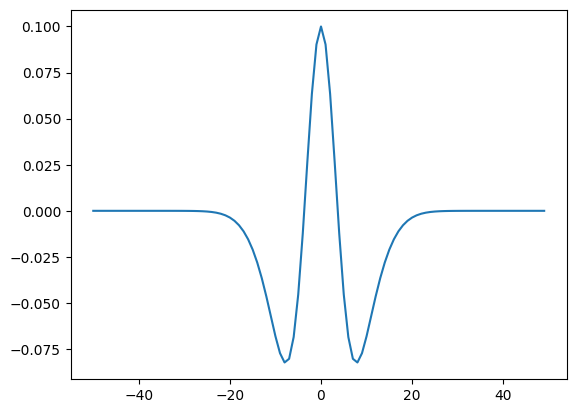

In [3]:
plt.plot(x, W)

0.4 Euler method

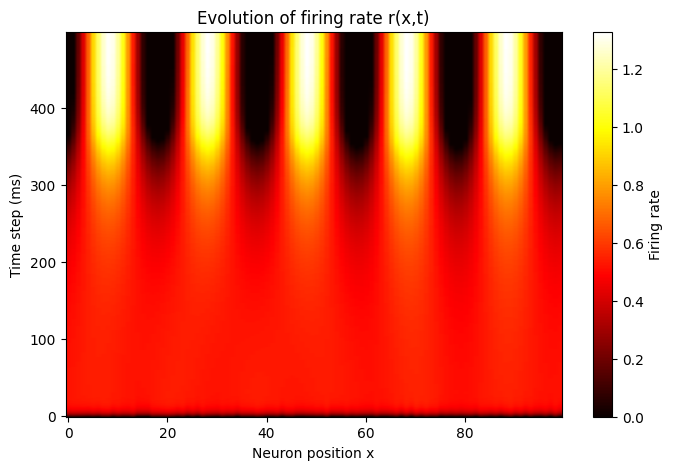

In [4]:
from scipy.ndimage import convolve1d

# parameters
M = 100
dt = 1.0
tau = 10.0
T = 500        
B = 1.0

A_exc = 0.3
sigma_exc = 5.0
A_inh = 0.2
sigma_inh = 10.0

x = np.linspace(-M/2, M/2, M, endpoint=False)

W = mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh)

np.random.seed(0)
s = np.random.uniform(0, 0.1, size=M)

r_history = np.zeros((T, M))

for t in range(T):
    r = relu(s)
    r_history[t] = r

    # periodic convolution
    I_rec = convolve1d(r, W, mode='wrap')

    # Euler update: tau ds/dt = -s + I_rec + B
    dsdt = (-s + I_rec + B) / tau
    s = s + dt * dsdt

plt.figure(figsize=(8, 5))
plt.imshow(r_history, aspect='auto', origin='lower', cmap='hot')
plt.colorbar(label='Firing rate')
plt.xlabel('Neuron position x')
plt.ylabel('Time step (ms)')
plt.title('Evolution of firing rate r(x,t)')
plt.show()